In [20]:
# %%
# IMPORT LIBRARIES
import sys
sys.path.insert(0, '..')
import helper_functions
from constants import *

import eelbrain
import matplotlib.pyplot as plt

SUBJECTS = helper_functions.get_subjects()


# Auditory Attention Decoding (AAD) Classifier
Classifying attention by the greatest correlation between predicted and actual signal

In [21]:
# %%
def aad_classifier(predictor, attention_att, attention_ign, model_type=MODEL_TYPE.FORWARD, padded=False, trf_dir=MAT_FILE_TRF_DIR):
    att_name = helper_functions.get_trf_model_name(predictor, attention_att, model_type, padded)
    ign_name = helper_functions.get_trf_model_name(predictor, attention_ign, model_type, padded)

    correct = 0
    total   = 0

    for subject in SUBJECTS:
        att_path = trf_dir / subject / f"{subject}_{att_name}_trf.pickle"
        ign_path = trf_dir / subject / f"{subject}_{ign_name}_trf.pickle"

        if not (att_path.exists() and ign_path.exists()):
            print(f"{subject}: missing files, skipping.")
            continue

        att  = eelbrain.load.unpickle(att_path)
        ign  = eelbrain.load.unpickle(ign_path)
        diff = att.r.mean() - ign.r.mean()

        correct += diff > 0
        total   += 1

    classifier = correct / total if total > 0 else 0.0
    incorrect  = total - correct

    print(f"Classification rate ({att_name} vs {ign_name}): {classifier:.2%}")

    plt.figure()
    plt.bar(['Correct', 'Incorrect'], [correct, incorrect])
    plt.title(f'{att_name.replace('_', ' ').title()}\nvs {ign_name.replace('_', ' ').title()}\nClassification rate: {classifier:.2%}')
    plt.xlabel('Outcome')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'aad_{att_name}_vs_{ign_name}.pdf')
    plt.show()

    return classifier

Classification rate (forward_attended_envelope vs forward_ignored_envelope): 83.33%


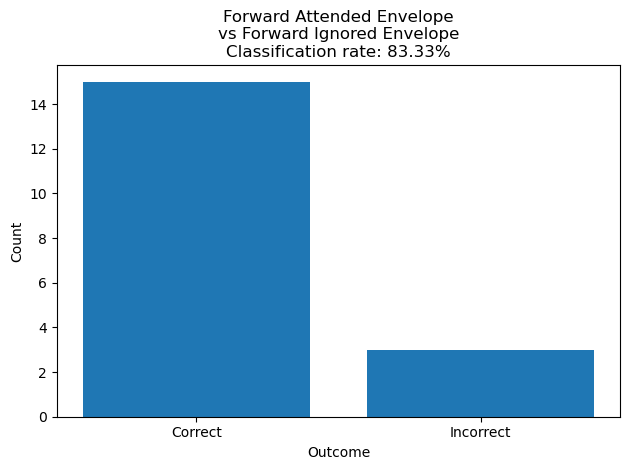

Classification rate (forward_attended_envelope_onset vs forward_ignored_envelope_onset): 83.33%


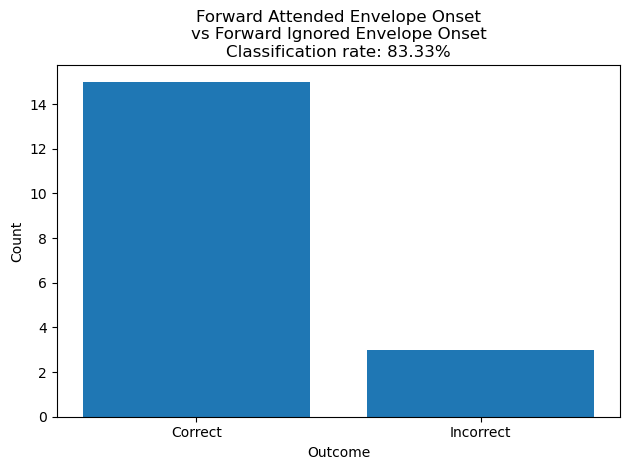

Classification rate (backward_attended_envelope vs backward_ignored_envelope): 94.44%


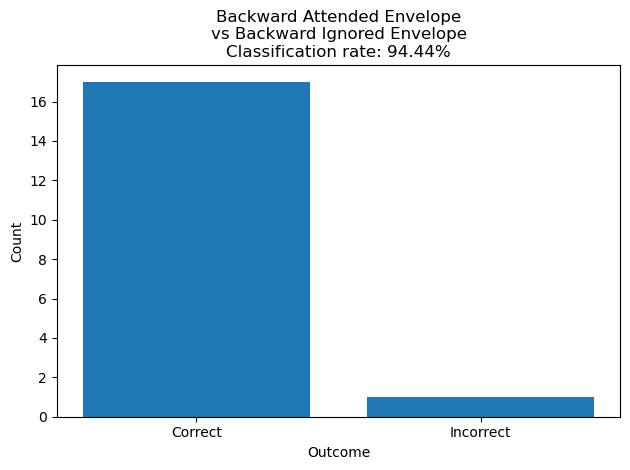

np.float64(0.9444444444444444)

In [22]:
# %%
# Envelope forward model
aad_classifier(PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.ATTENDED, ATTENTION_TYPE.IGNORED)

# %%
# Envelope onset forward model
aad_classifier(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, ATTENTION_TYPE.IGNORED)

# %%
# Backward (decoder) model
aad_classifier(PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.ATTENDED, ATTENTION_TYPE.IGNORED, model_type=MODEL_TYPE.BACKWARD)